# Segmentación interactiva con GrabCut

Este cuaderno presenta el algoritmo **GrabCut** para la segmentación interactiva de lesiones en imágenes de resonancia magnética cerebral.

El método se estudiará en dos etapas:

1. **Implementación didáctica:** se desarrollarán paso a paso los principales componentes matemáticos de GrabCut: modelo de mezclas gaussianas, costos de apariencia, coherencia espacial, construcción del grafo y corte mínimo.
2. **Implementación con OpenCV:** se utilizará `cv2.grabCut` para observar cómo estos pasos son encapsulados por una implementación optimizada.

Finalmente, ambas segmentaciones se compararán con una máscara de referencia mediante el **error cuadrático medio (ECM)**.

In [26]:
%matplotlib widget

from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

## 2. Imagen de trabajo

Sea $x_i$ la intensidad del píxel $i$ de una imagen en escala de grises.

Para desarrollar el algoritmo se utilizará un único caso como ejemplo. Cada caso del conjunto de datos está identificado mediante la convención `VS-SEG-XXX`.

La imagen original se encuentra en:

```text
data/images/
```

Durante las siguientes secciones, esta imagen permitirá construir paso a paso los modelos probabilísticos y espaciales utilizados por GrabCut.

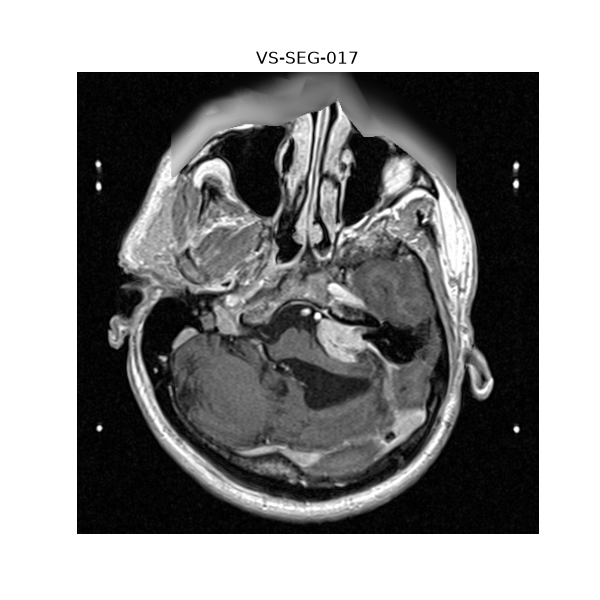

In [27]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

case_id = "VS-SEG-017"
image_path = DATA_DIR / "images" / f"{case_id}.png"

image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray")
plt.title(case_id)
plt.axis("off")
plt.show()

## 3. Selección interactiva de la ROI

GrabCut utiliza una **región de interés (ROI)** para inicializar la segmentación.

La ROI se representa mediante el rectángulo

$$
R=(x,y,w,h),
$$

donde $(x,y)$ corresponde a la esquina superior izquierda, mientras que $w$ y $h$ representan su ancho y altura.

El usuario selecciona una región que contiene la lesión y parte del tejido circundante. Los píxeles exteriores se utilizarán inicialmente como **fondo seguro**, mientras que los píxeles interiores constituirán la región candidata para la segmentación.

El rectángulo rojo puede reajustarse interactivamente y no representa el contorno final de la lesión; únicamente proporciona la inicialización espacial del algoritmo.

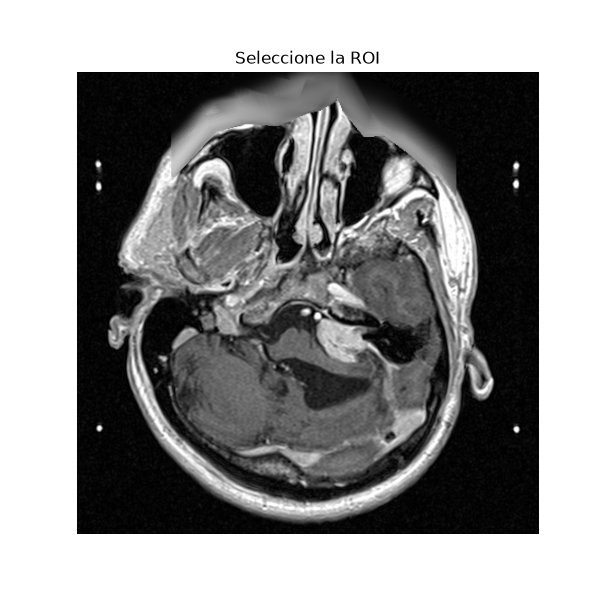

In [28]:
from matplotlib.widgets import RectangleSelector


class ROISelector:
    def __init__(self, image):
        self.image = image
        self.fig = None
        self.ax = None
        self.selector = None
        self.roi = None

    def _on_select(self, eclick, erelease):
        x1, x2, y1, y2 = self.selector.extents

        x = int(min(x1, x2))
        y = int(min(y1, y2))
        w = int(abs(x2 - x1))
        h = int(abs(y2 - y1))

        self.roi = (x, y, w, h)

    def show(self):
        self.fig, self.ax = plt.subplots(figsize=(6, 6))

        self.ax.imshow(self.image, cmap="gray")
        self.ax.set_title("Seleccione la ROI")
        self.ax.axis("off")

        self.selector = RectangleSelector(
            self.ax,
            self._on_select,
            button=[1],
            interactive=True,
            useblit=False,
            minspanx=5,
            minspany=5,
            spancoords="pixels",
            props={
                "edgecolor": "red",
                "facecolor": "red",
                "alpha": 0.2,
                "fill": True,
            },
        )

        plt.show()
        return self


roi_selector = ROISelector(image).show()